## Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Looking at the dataset

In [3]:
df = pd.read_csv(r'cleaned.csv')
print(df.head())

  Product_ID         Brand     Category  Price_INR  Units_Sold  \
0   PROD0001         Lakme   Foundation    2672.70          16   
1   PROD0002  Faces Canada     Lipstick     656.53          42   
2   PROD0003        Revlon  Highlighter    1049.53          14   
3   PROD0004  Faces Canada     Eyeliner     273.88          25   
4   PROD0005           MAC   Foundation    3072.61          25   

   Discount_Percent  Revenue_INR  Rating  Customer_Age Customer_Gender  ...  \
0                 5     40625.04     3.1            22          Female  ...   
1                 0     27574.26     4.3            42          Female  ...   
2                15     12489.41     4.9            37          Female  ...   
3                15      5819.95     2.7            34          Female  ...   
4                10     69133.73     3.2            39          Female  ...   

      Month Quarter Day_of_Week Is_weekend  Price_Range    Age_Group  \
0  February       1      Friday          0      Premium 

## Does giving discounts increase sales and revenue?

                  Revenue_INR  Units_Sold
Discount_Percent                         
0                 28178323.99       24.03
5                 12004165.20       26.05
10                12592882.15       25.43
15                 6821244.60       25.67
20                 6204796.82       25.45
25                 2350910.57       24.72



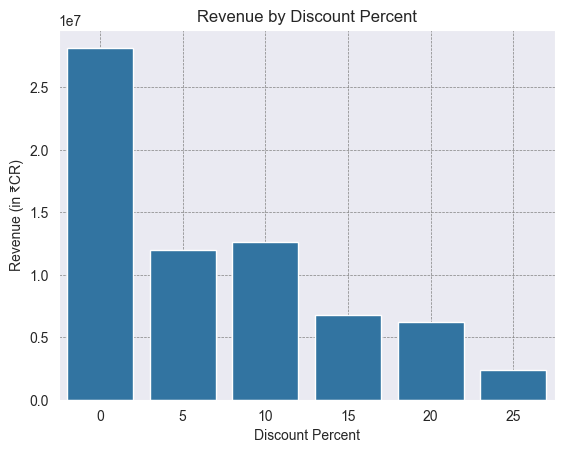

In [4]:
q0 = df.groupby("Discount_Percent").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2),
    "Units_Sold": lambda x: round(x.mean(), 2)
})

print(q0)
print()

sns.barplot(data=q0,  x="Discount_Percent", y="Revenue_INR")
plt.title("Revenue by Discount Percent")
plt.xlabel("Discount Percent")
plt.ylabel("Revenue (in ₹CR)")
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

The analysis shows that non-discounted products generated higher overall revenue than discounted products, indicating that discounts may not be the primary driver of sales performance.

## Which brands generate the highest revenue

          Brand  Revenue_INR  Units_Sold
7         Nykaa   7813214.54       24.93
6           NYX   7325519.99       25.32
5    Maybelline   7254528.77       26.31
0      Colorbar   7148850.27       24.88
2       L'Oreal   7111380.43       25.28
8        Revlon   6856934.35       24.48
3         Lakme   6489709.37       23.70
4           MAC   6359673.51       25.40
1  Faces Canada   5976840.97       23.47
9         Sugar   5815671.13       25.90



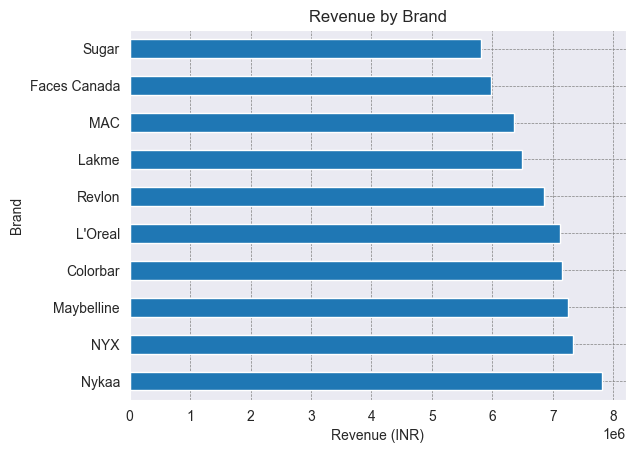

In [5]:
q1 = df.groupby("Brand").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2),
    "Units_Sold": lambda x: round(x.mean(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q1)
print()

q1.plot(kind="barh", x="Brand", y="Revenue_INR", legend=False)
plt.title("Revenue by Brand")
plt.xlabel("Revenue (INR)")
plt.ylabel("Brand")
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

Nykaa leads the revenue chart with ₹7,813,214.54, making it the top-performing brand in this dataset. This indicates its strong market presence and consumer preference compared to other competitors.

## Which categories generate the highest sales and revenue

        Category  Revenue_INR  Units_Sold
2       Eyeliner   3752706.22       25.04
7        Mascara   4980034.52       23.30
9  Setting Spray   5249184.83       24.71
0          Blush   5961525.01       24.74
6       Lipstick   6571373.17       26.03
1      Concealer   7289966.98       25.92
8         Primer   7697616.00       25.39
5    Highlighter   8206337.96       26.01
4     Foundation   8212245.69       23.11
3      Eyeshadow  10231332.95       25.48



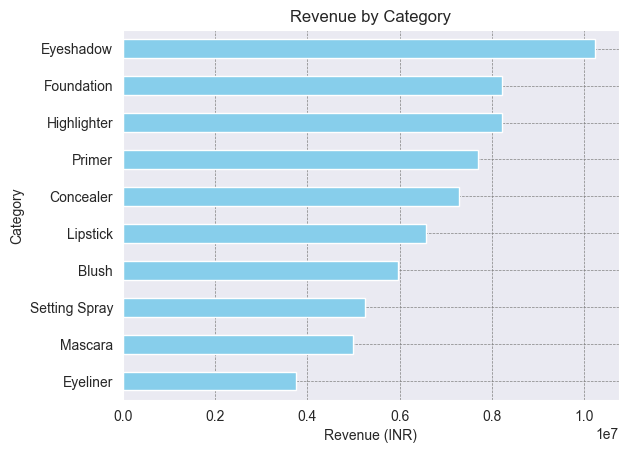

In [6]:
q2 = df.groupby("Category").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2),
    "Units_Sold": lambda x: round(x.mean(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=True)

print(q2)
print()

q2.plot(kind="barh", x="Category", y="Revenue_INR", legend=False, color="skyblue")
plt.title("Revenue by Category")
plt.xlabel("Revenue (INR)")
plt.ylabel("Category")
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

Eyeshadow leads all categories with ₹10,231,332.95 in revenue, making it the top-performing product.

## Which region generates the highest sales and revenue

      Region  Revenue_INR  Units_Sold
1  Bangalore   9139093.06       25.28
5    Kolkata   8765765.18       23.67
4  Hyderabad   8760530.66       25.63
0  Ahmedabad   8757033.26       26.27
2    Chennai   8691412.14       23.82
7       Pune   8259679.19       24.85
3      Delhi   8194546.62       25.34
6     Mumbai   7584263.22       24.82



Text(0, 0.5, 'Region')

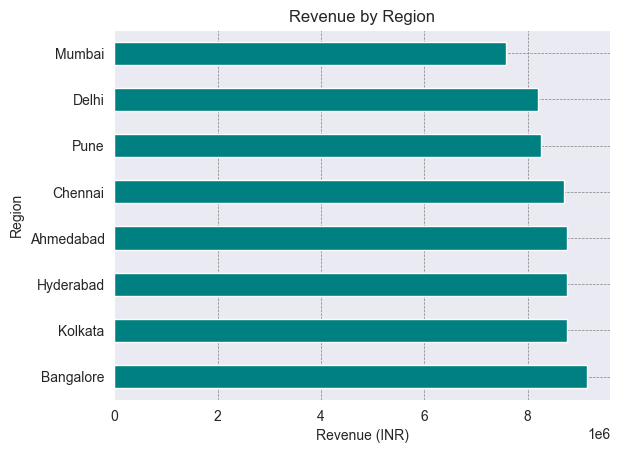

In [7]:
q3 = df.groupby("Region").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2),
    "Units_Sold": lambda x: round(x.mean(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q3)
print()

q3.plot(kind="barh", x="Region", y="Revenue_INR", legend=False, color="teal")
plt.title("Revenue by Region")
plt.xlabel("Revenue (INR)")
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.ylabel("Region")

Bangalore ranks highest in both revenue and sales, generating ₹9,139,093.06 with 25.28 units sold. This reflects its strong consumer base and market dominance among all listed regions.

## Which sales channel generates the highest revenue

  Sales_Channel  Revenue_INR  Units_Sold
1        Online  23270224.13       24.86
2  Retail Store  23190085.17       25.37
0   Brand Store  21692014.03       24.65



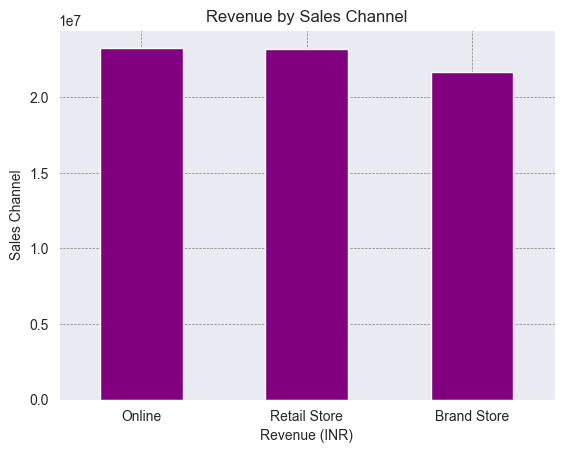

In [8]:
q4 = df.groupby("Sales_Channel").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2),
    "Units_Sold": lambda x: round(x.mean(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q4)
print()

q4.plot(kind="bar", x="Sales_Channel", y="Revenue_INR", legend=False, color="purple")
plt.title("Revenue by Sales Channel")
plt.xlabel("Revenue (INR)")
plt.ylabel("Sales Channel")
plt.xticks(rotation=0)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

The **Online channel** generates the highest revenue at ₹23,270,224.13, outperforming both retail and brand stores. This highlights the growing dominance of digital platforms in driving sales performance.

## Which month generates the highest sales

        Month  Revenue_INR  Units_Sold
8         May   6327024.52       26.49
4     January   6277417.86       25.88
6        June   6216196.40       24.88
2    December   5922491.92       24.07
7       March   5901923.78       24.44
1      August   5803597.86       25.60
10    October   5702173.40       23.10
5        July   5286090.70       24.65
9    November   5241810.72       25.18
11  September   5212477.23       24.09
0       April   5148948.15       25.30
3    February   5112170.79       26.04



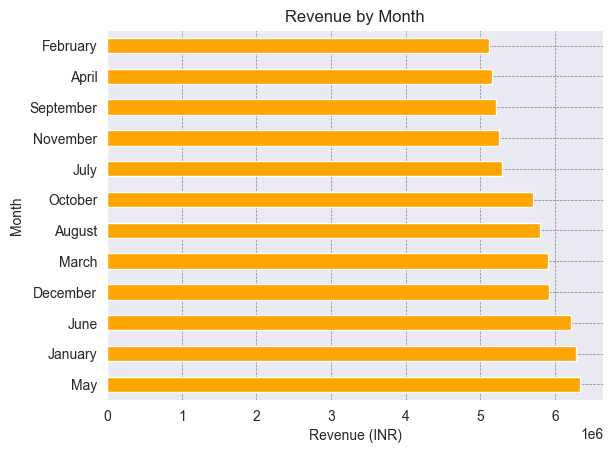

In [9]:
q5 = df.groupby("Month").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2),
    "Units_Sold": lambda x: round(x.mean(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q5)
print()

q5.plot(kind="barh", x="Month", y="Revenue_INR", legend=False, color="orange")
plt.title("Revenue by Month")
plt.xlabel("Revenue (INR)")
plt.ylabel("Month")
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

The May month generates the highest revenue making it the most busiest months followed by January and June.

## In which season is peak revenue generated

   Quarter  Revenue_INR
1        2  17692169.07
0        1  17291512.43
3        4  16866476.04
2        3  16302165.79



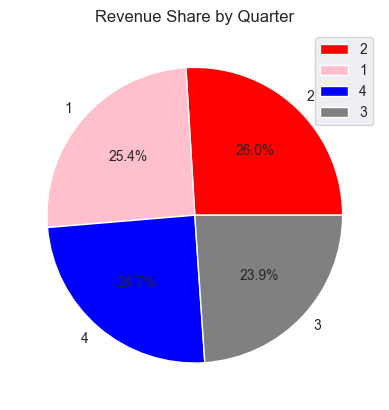

In [10]:
q6 = df.groupby("Quarter").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q6)
print()

q6.plot(kind="pie", y="Revenue_INR", labels=q6["Quarter"], autopct="%1.1f%%", colors=["red","pink","blue","grey"])
plt.title("Revenue Share by Quarter")
plt.ylabel("")
plt.show()

The 2nd Quarter generates the peak revenue.

—## Are sales higher during weekends

   Is_weekend  Revenue_INR
0           0  49994102.60
1           1  18158220.73



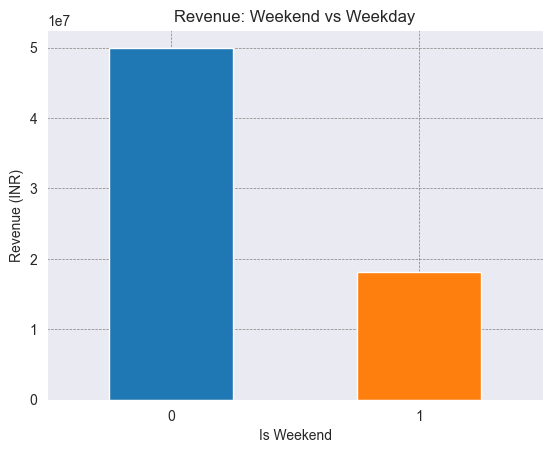

In [11]:
q7 = df.groupby("Is_weekend").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q7)
print()

q7.plot(kind="bar", x="Is_weekend", y="Revenue_INR", legend=False, color=["#1f77b4","#ff7f0e"])
plt.title("Revenue: Weekend vs Weekday")
plt.xlabel("Is Weekend")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=0)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

Weekday sales outperform weekend sales significantly, with total revenue reaching ₹49,994,102.60 compared to ₹18,158,220.73 on weekends. This indicates stronger consumer activity and higher transaction volumes during weekdays.

## Which products contribute the most to total revenue

       Brand       Category  Revenue_INR
73     Nykaa      Eyeshadow   1468582.64
33     Lakme      Eyeshadow   1422504.07
4   Colorbar     Foundation   1420564.60
83    Revlon      Eyeshadow   1397505.12
65       NYX    Highlighter   1210269.46
..       ...            ...          ...
36     Lakme       Lipstick    269959.25
89    Revlon  Setting Spray    266686.07
62       NYX       Eyeliner    264566.34
92     Sugar       Eyeliner    252594.82
77     Nykaa        Mascara    230333.31

[100 rows x 3 columns]



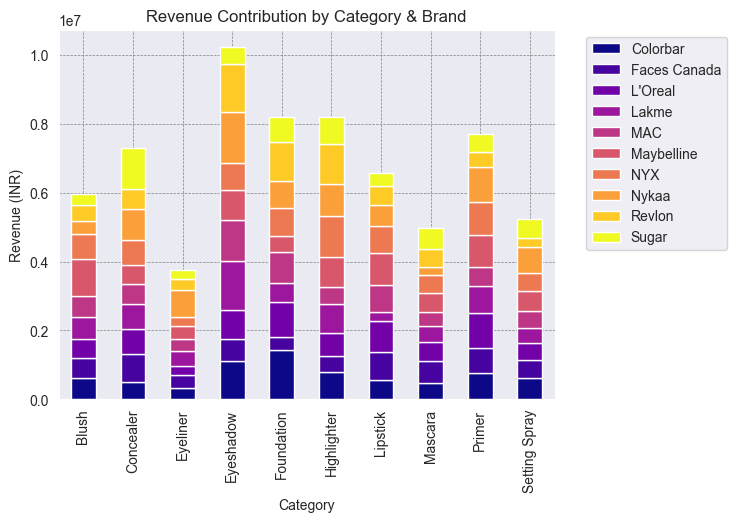

In [12]:
q8 = df.groupby(["Brand", "Category"]).agg({
    "Revenue_INR": lambda x: round(x.sum(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q8)
print()

ax = q8.pivot(index="Category", columns="Brand", values="Revenue_INR").plot(
    kind="bar", stacked=True, colormap="plasma"
)
plt.title("Revenue Contribution by Category & Brand")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Nykaa’s **Eyeshadow** category contributes the most to total revenue at ₹1,468,582.64, followed closely by Lakme’s Eyeshadow and Colorbar’s Foundation. This highlights strong performance in eye and base makeup segments across leading brands.

## Which price range generates maximum revenue

In [13]:
q9 = df.groupby("Price_Range").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

  Price_Range  Revenue_INR
2     Premium  46279986.92
1   Mid-Range  19911496.36
0      Budget   1960840.05



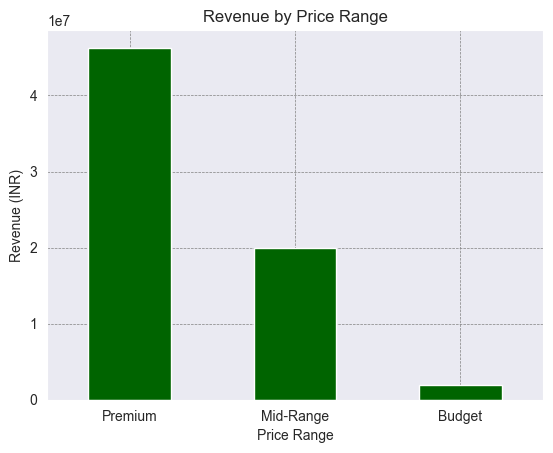

In [14]:
q9 = df.groupby("Price_Range").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q9)
print()

q9.plot(kind="bar", x="Price_Range", y="Revenue_INR", legend=False, color="darkgreen")
plt.title("Revenue by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=0)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

The **Premium price range** generates the highest revenue at ₹46,279,986.92, far surpassing mid-range and budget categories. This indicates that consumers show a strong preference for high-end products, driving greater profitability.

## Which age group purchases the most products?

     Age_Group  Revenue_INR  Units_Sold
0       Mature  51800267.92       37929
1  Young Adult  16352055.41       12002



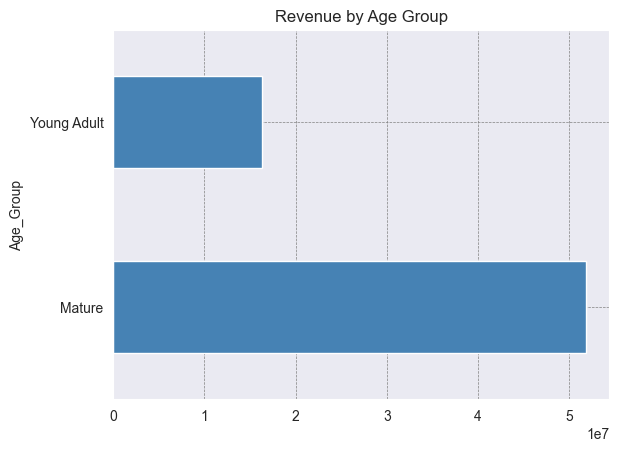

In [15]:
q1 = df.groupby("Age_Group").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2),
    "Units_Sold": "sum"
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q1)
print()

q1.plot(kind="barh", x="Age_Group", y="Revenue_INR", legend=False, color="steelblue")
plt.title("Revenue by Age Group")
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

The **Mature age group** contributes the most to total purchases, generating ₹51,800,267.92 in revenue with 37,929 units sold. This indicates that older consumers are the primary drivers of sales compared to younger adults.

## Which gender purchases the most?

  Customer_Gender  Revenue_INR  Units_Sold
0          Female  53833400.56       39624
1            Male   8034355.52        5930
2      Non-binary   6284567.25        4377



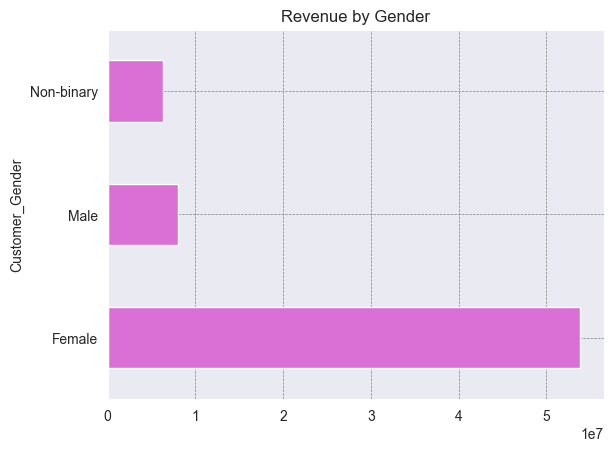

In [16]:
q2 = df.groupby("Customer_Gender").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2),
    "Units_Sold": "sum"
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q2)
print()

q2.plot(kind="barh", x="Customer_Gender", y="Revenue_INR", legend=False, color="orchid")
plt.title("Revenue by Gender")
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

Female customers dominate overall purchases, contributing ₹53,833,400.56 in revenue with 39,624 units sold. This clearly shows that women drive the majority of sales and revenue in the dataset.

## Which skin type generates the highest sales?

     Skin_Type  Revenue_INR  Units_Sold
4    Sensitive  14660208.19       10611
1          Dry  14340362.03       10657
3         Oily  13547540.52        9982
0  Combination  13434094.64        9680
2       Normal  12170117.95        9001



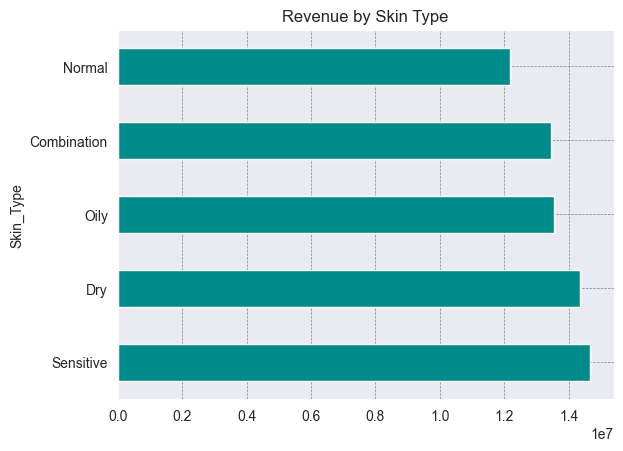

In [17]:
q3 = df.groupby("Skin_Type").agg({
    "Revenue_INR": lambda x: round(x.sum(), 2),
    "Units_Sold": "sum"
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q3)
print()

q3.plot(kind="barh", x="Skin_Type", y="Revenue_INR", legend=False, color="darkcyan")
plt.title("Revenue by Skin Type")
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

The **Sensitive skin type** generates the highest sales, contributing ₹14,660,208.19 in revenue with 10,611 units sold. This suggests that products catering to sensitive skin have the strongest market demand and consumer engagement.

## Which customer segment spends the most per order?

     Age_Group  Revenue_INR
1  Young Adult     34644.19
0       Mature     33900.70



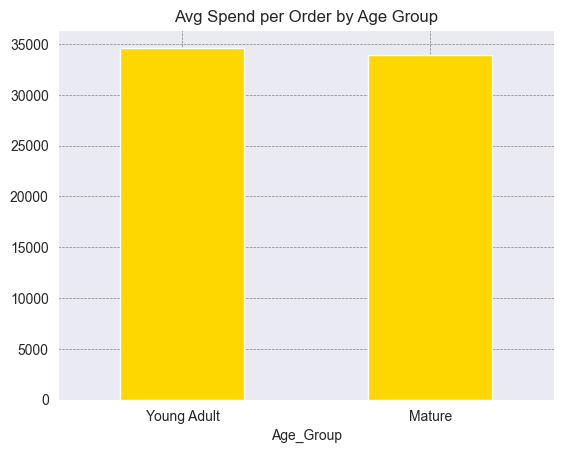

In [18]:
q4 = df.groupby("Age_Group").agg({
    "Revenue_INR": lambda x: round(x.mean(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q4)
print()

q4.plot(kind="bar", x="Age_Group", y="Revenue_INR", legend=False, color="gold")
plt.title("Avg Spend per Order by Age Group")
plt.xticks(rotation=0)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

The **Young Adult** segment spends the most per order, averaging ₹34,644.19 compared to ₹33,900.70 for the Mature group. This suggests younger consumers tend to make higher-value purchases per transaction.

## Which age group prefers premium products?

     Age_Group  Premium_Products
0       Mature               686
1  Young Adult               212



C:\Users\USER\AppData\Local\Temp\ipykernel_20408\839298423.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  q5 = df.groupby("Age_Group").apply(


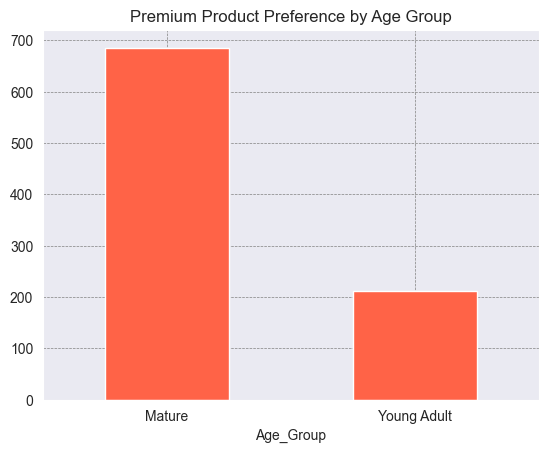

In [19]:
q5 = df.groupby("Age_Group").apply(
    lambda g: pd.Series({"Premium_Products": (df.loc[g.index,"Price_Range"]=="Premium").sum()})
).reset_index().sort_values("Premium_Products", ascending=False)

print(q5)
print()

q5.plot(kind="bar", x="Age_Group", y="Premium_Products", legend=False, color="tomato")
plt.title("Premium Product Preference by Age Group")
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.xticks(rotation=0)
plt.show()

The **Mature age group** shows a stronger preference for premium products, purchasing 686 items compared to 212 by young adults. This indicates that older consumers are more inclined toward high-end, luxury offerings.

## Which combinations of age group and skin type generate the highest revenue?

     Age_Group    Skin_Type  Revenue_INR
0       Mature  Combination  11055601.83
4       Mature    Sensitive  10967817.76
1       Mature          Dry  10613817.93
3       Mature         Oily  10508536.86
2       Mature       Normal   8654493.54
6  Young Adult          Dry   3726544.10
9  Young Adult    Sensitive   3692390.43
7  Young Adult       Normal   3515624.41
8  Young Adult         Oily   3039003.66
5  Young Adult  Combination   2378492.81



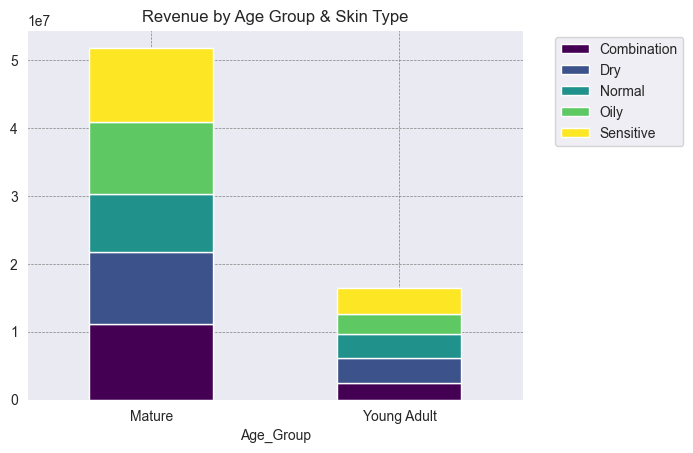

In [20]:
q6 = df.groupby(["Age_Group","Skin_Type"]).agg({
    "Revenue_INR": lambda x: round(x.sum(), 2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q6)
print()

q6.pivot(index="Age_Group", columns="Skin_Type", values="Revenue_INR").plot(kind="bar", stacked=True, colormap="viridis")
plt.title("Revenue by Age Group & Skin Type")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

The **Mature–Combination skin type** group generates the highest revenue at ₹11,055,601.83, followed closely by **Mature–Sensitive** and **Mature–Dry** segments. This indicates that mature consumers with combination or sensitive skin are the most valuable demographic for sales performance.

## What percentage of revenue comes from discounted sales?

   Discounted_Revenue  Total_Revenue  Discounted_Revenue_Percent
0         39973999.34    68152323.33                       58.65



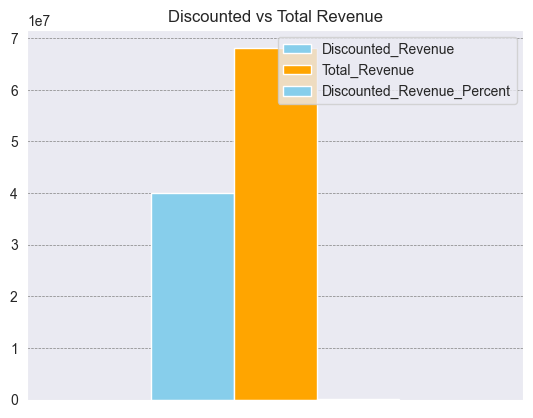

In [21]:
q7 = pd.DataFrame({
    "Discounted_Revenue":[round(df.loc[df["Discount_Percent"]>0,"Revenue_INR"].sum(),2)],
    "Total_Revenue":[round(df["Revenue_INR"].sum(),2)]
})
q7["Discounted_Revenue_Percent"] = round(q7["Discounted_Revenue"]/q7["Total_Revenue"]*100,2)

print(q7)
print()

q7.plot(kind="bar", legend=True, color=["skyblue","orange"])
plt.title("Discounted vs Total Revenue")
plt.xticks([])
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

Discounted sales account for **58.65%** of total revenue, contributing ₹39,973,999.34 out of ₹68,152,323.33. This shows that discounts play a major role in driving overall sales performance and customer engagement.

## Is higher pricing associated with lower sales volume?

  Price_Range  Units_Sold  Revenue_INR
2     Premium       24.69  46279986.92
0      Budget       24.85   1960840.05
1   Mid-Range       25.29  19911496.36



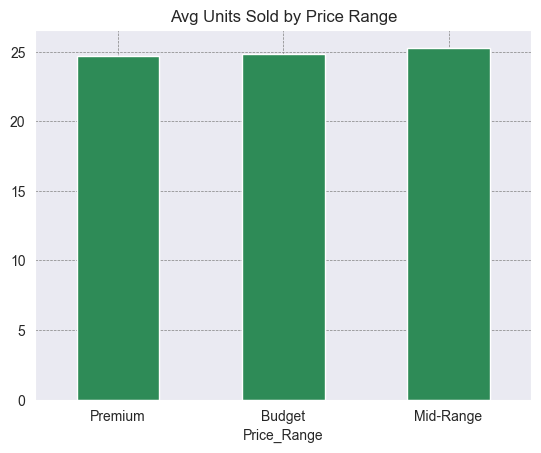

In [22]:
q8 = df.groupby("Price_Range").agg({
    "Units_Sold": lambda x: round(x.mean(),2),
    "Revenue_INR": lambda x: round(x.sum(),2)
}).reset_index().sort_values("Units_Sold", ascending=True)

print(q8)
print()

q8.plot(kind="bar", x="Price_Range", y="Units_Sold", legend=False, color="seagreen")
plt.title("Avg Units Sold by Price Range")
plt.xticks(rotation=0)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

Yes — the data suggests a mild inverse relationship between price and sales volume. Premium products have slightly lower average units sold (24.69) compared to mid-range (25.29) and budget (24.85) categories, indicating that higher pricing tends to reduce purchase quantity even though revenue remains strong.

## Optimal discount range for maximizing revenue?

  Discount_Percent  Revenue_INR  Units_Sold
0      No Discount  28178323.99       24.03
1      Low (1-10%)  24597047.35       25.71
2  Medium (11-20%)  13026041.42       25.56
3    High (21-25%)   2350910.57       24.72



C:\Users\USER\AppData\Local\Temp\ipykernel_20408\1077662435.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q9 = df.groupby(pd.cut(df["Discount_Percent"],


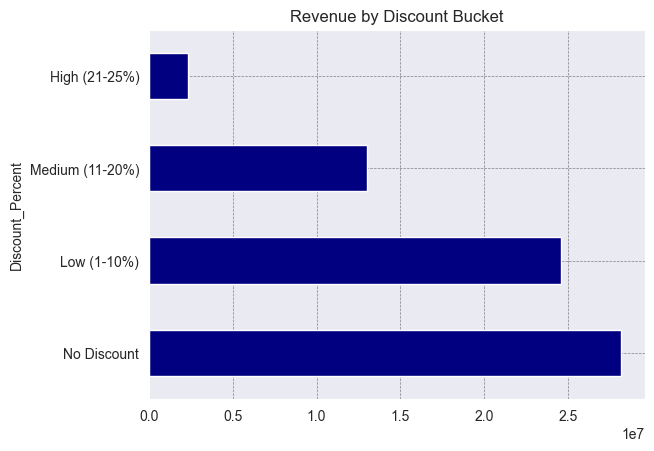

In [23]:
q9 = df.groupby(pd.cut(df["Discount_Percent"],
                       bins=[-1,0,10,20,25],
                       labels=["No Discount","Low (1-10%)","Medium (11-20%)","High (21-25%)"]
                      )).agg({
    "Revenue_INR": lambda x: round(x.sum(),2),
    "Units_Sold": lambda x: round(x.mean(),2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q9)
print()

q9.plot(kind="barh", x="Discount_Percent", y="Revenue_INR", legend=False, color="navy")
plt.title("Revenue by Discount Bucket")
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

The analysis shows that **no discount** yields the highest revenue at ₹28,178,323.99, followed by **low discounts (1–10%)** at ₹24,597,047.35. This suggests that minimal or no discounting is most effective for maximizing revenue, while higher discounts reduce overall profitability.

## Which brands depend heavily on discounts?

C:\Users\USER\AppData\Local\Temp\ipykernel_20408\4186757224.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  q10 = df.groupby("Brand").apply(


          Brand  Discounted_Revenue_Percent  Revenue_INR
3         Lakme                       65.38   6489709.37
9         Sugar                       61.30   5815671.13
5    Maybelline                       60.57   7254528.77
4           MAC                       58.43   6359673.51
2       L'Oreal                       57.99   7111380.43
7         Nykaa                       57.65   7813214.54
8        Revlon                       57.46   6856934.35
0      Colorbar                       56.90   7148850.27
6           NYX                       56.64   7325519.99
1  Faces Canada                       54.74   5976840.97



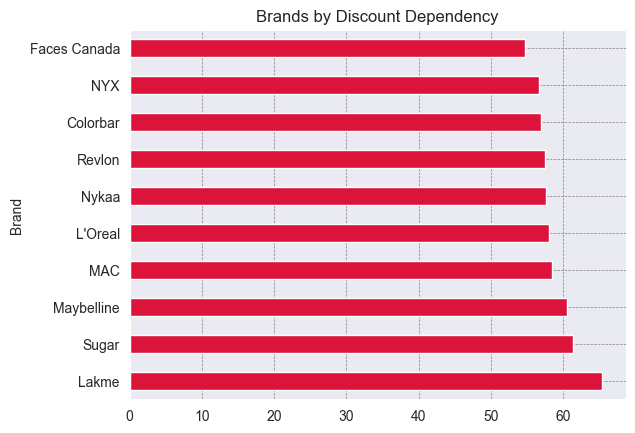

In [24]:
q10 = df.groupby("Brand").apply(
    lambda g: pd.Series({
        "Discounted_Revenue_Percent": round(
            g.loc[g["Discount_Percent"] > 0, "Revenue_INR"].sum() / g["Revenue_INR"].sum() * 100, 2
        ),
        "Revenue_INR": round(g["Revenue_INR"].sum(), 2)
    })
).reset_index().sort_values("Discounted_Revenue_Percent", ascending=False)

print(q10)
print()

q10.plot(kind="barh", x="Brand", y="Discounted_Revenue_Percent", legend=False, color="crimson")
plt.title("Brands by Discount Dependency")
plt.xticks(rotation=0)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

Lakme depends most heavily on discounts, with **65.38%** of its total revenue coming from discounted sales. This suggests that Lakme’s performance is strongly influenced by promotional pricing compared to other brands like Sugar and Maybelline, which also show high discount dependency but slightly lower percentages.

## Which brands contribute the highest percentage of total revenue?

          Brand  Revenue_INR  Revenue_Percentage
0      Colorbar   7148850.27               10.49
1  Faces Canada   5976840.97                8.77
2       L'Oreal   7111380.43               10.43
3         Lakme   6489709.37                9.52
4           MAC   6359673.51                9.33
5    Maybelline   7254528.77               10.64
6           NYX   7325519.99               10.75
7         Nykaa   7813214.54               11.46
8        Revlon   6856934.35               10.06
9         Sugar   5815671.13                8.53



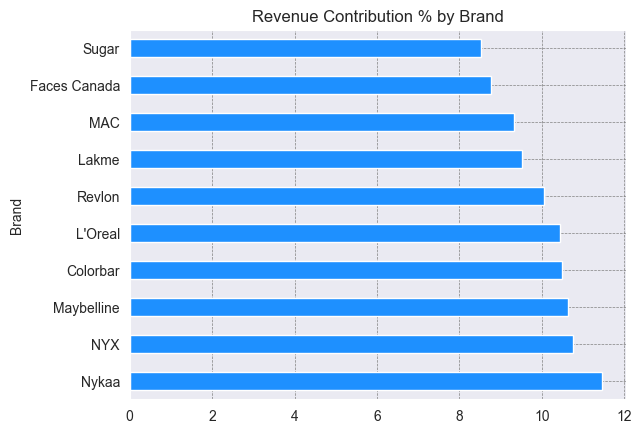

In [25]:
q11 = df.groupby("Brand").agg({
    "Revenue_INR": lambda x: round(x.sum(),2)
}).reset_index()
total_rev = q11["Revenue_INR"].sum()
q11["Revenue_Percentage"] = round(q11["Revenue_INR"]/total_rev*100,2)

print(q11)
print()

q11.sort_values("Revenue_Percentage", ascending=False).plot(kind="barh", x="Brand", y="Revenue_Percentage", legend=False, color="dodgerblue")
plt.title("Revenue Contribution % by Brand")
plt.xticks(rotation=0)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

From the data, **Nykaa** contributes the highest percentage of total revenue at **11.46%**, followed by **NYX (10.75%)** and **Maybelline (10.64%)**. These three brands are the top performers, collectively driving over **32%** of total revenue — a clear indication of their strong market presence and customer appeal.

## Which products generate high revenue but low ratings?

    Brand   Category  Revenue_INR  Rating
63    NYX  Eyeshadow    784269.02    3.47
96  Sugar   Lipstick    367989.40    3.43



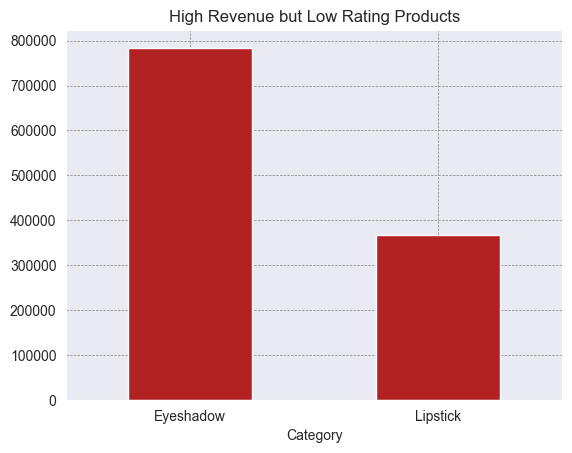

In [26]:
q12 = df.groupby(["Brand","Category"]).agg({
    "Revenue_INR": lambda x: round(x.sum(),2),
    "Rating": lambda x: round(x.mean(),2)
}).reset_index()
q12 = q12[(q12["Revenue_INR"]>0)&(q12["Rating"]<3.5)].sort_values("Revenue_INR", ascending=False)

print(q12)
print()

q12.plot(kind="bar", x="Category", y="Revenue_INR", legend=False, color="firebrick")
plt.title("High Revenue but Low Rating Products")
plt.xticks(rotation=0)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

From the analysis, **NYX Eyeshadow** and **Sugar Lipstick** stand out as products that generate high revenue but have relatively low ratings — 3.47 and 3.43 respectively. This suggests strong sales performance despite moderate customer satisfaction, possibly due to effective marketing or brand loyalty outweighing product experience.

## Which products generate high sales but low customer satisfaction?

In [27]:
q13 = df.groupby(["Brand","Category"]).agg({
    "Units_Sold": "sum",
    "Rating": lambda x: round(x.mean(),2)
}).reset_index()

q13 = q13[(q13["Units_Sold"] > 0) & (q13["Rating"] < 3)].sort_values("Units_Sold", ascending=False)

print(q13)
print()

if not q13.empty:
    q13.plot(kind="bar", x="Category", y="Units_Sold", legend=False, color="darkorange")
    plt.title("High Sales but Low Satisfaction Products")
    plt.xticks(rotation=90)
    plt.grid(color="grey", linestyle="--", linewidth=0.5)
    plt.show()
else:
    print("No products found with high sales and low satisfaction.")

Empty DataFrame
Columns: [Brand, Category, Units_Sold, Rating]
Index: []

No products found with high sales and low satisfaction.


## Which categories perform best in each region?

       Region       Category  Revenue_INR
8   Ahmedabad         Primer   1343823.17
5   Ahmedabad    Highlighter   1215693.55
3   Ahmedabad      Eyeshadow   1119541.96
6   Ahmedabad       Lipstick    971425.84
4   Ahmedabad     Foundation    908052.95
..        ...            ...          ...
76       Pune       Lipstick    804537.61
70       Pune          Blush    798824.52
79       Pune  Setting Spray    778428.97
72       Pune       Eyeliner    667092.89
77       Pune        Mascara    377234.12

[80 rows x 3 columns]



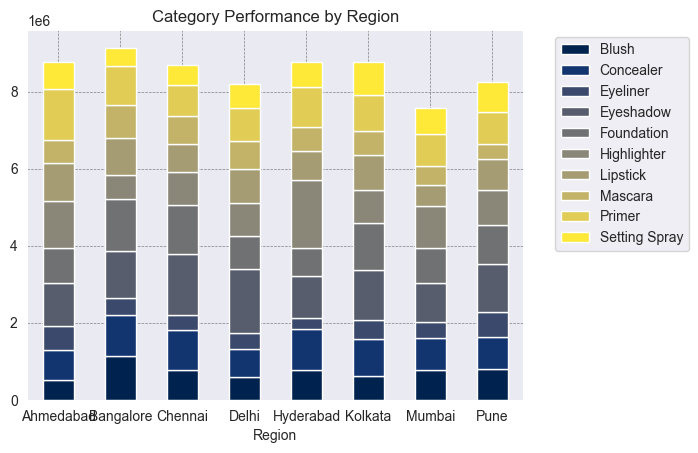

In [28]:
q14 = df.groupby(["Region","Category"]).agg({
    "Revenue_INR": lambda x: round(x.sum(),2)
}).reset_index().sort_values(["Region","Revenue_INR"], ascending=[True,False])

print(q14)
print()

q14.pivot(index="Region", columns="Category", values="Revenue_INR").plot(kind="bar", stacked=True, colormap="cividis")
plt.title("Category Performance by Region")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

## Which brands have the highest average customer ratings?

          Brand  Rating
3         Lakme    3.89
8        Revlon    3.81
0      Colorbar    3.80
5    Maybelline    3.79
1  Faces Canada    3.78
6           NYX    3.75
7         Nykaa    3.75
9         Sugar    3.75
4           MAC    3.74
2       L'Oreal    3.72



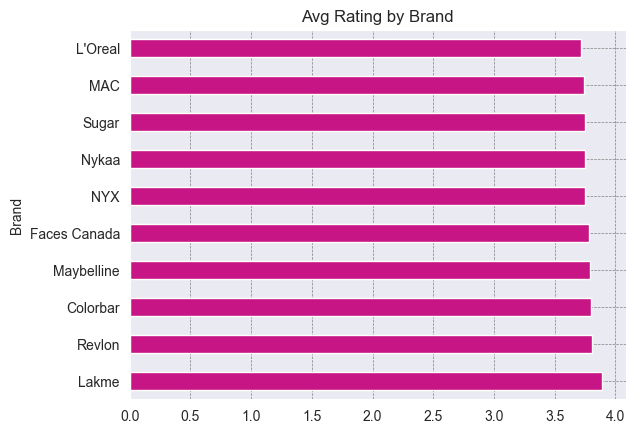

In [29]:
q15 = df.groupby("Brand").agg({
    "Rating": lambda x: round(x.mean(),2)
}).reset_index().sort_values("Rating", ascending=False)

print(q15)
print()

q15.plot(kind="barh", x="Brand", y="Rating", legend=False, color="mediumvioletred")
plt.title("Avg Rating by Brand")
plt.xticks(rotation=0)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

From the data, **Lakme** leads with the highest average customer rating of **3.89**, followed by **Revlon (3.81)** and **Colorbar (3.80)**. These brands stand out for consistently positive customer feedback, suggesting strong product satisfaction and brand trust among buyers.

## Do highly rated products generate higher revenue?

   High_Rating  Revenue_INR
0            0  38483681.28
1            1  29668642.05



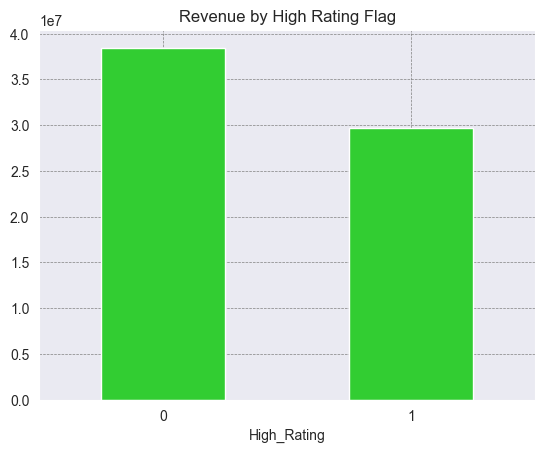

In [30]:
q16 = df.groupby("High_Rating").agg({
    "Revenue_INR": lambda x: round(x.sum(),2)
}).reset_index().sort_values("Revenue_INR", ascending=False)

print(q16)
print()

q16.plot(kind="bar", x="High_Rating", y="Revenue_INR", legend=False, color="limegreen")
plt.title("Revenue by High Rating Flag")
plt.xticks(rotation=0)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

##  Which products have low ratings and low sales?

## Which products have low ratings and low sales?

In [31]:
q17 = df.groupby(["Brand","Category"]).agg({
    "Units_Sold": "sum",
    "Rating": lambda x: round(x.mean(),2)
}).reset_index()
q17 = q17[(q17["Units_Sold"]<50)&(q17["Rating"]<3)].sort_values(["Units_Sold","Rating"], ascending=[True,True])

if not q17.empty:
    q17.plot(kind="bar", x="Category", y="Units_Sold", legend=False, color="slateblue")
    plt.title("Low Rating & Low Sales Products")
    plt.xticks(rotation=90)
    plt.grid(color="grey", linestyle="--", linewidth=0.5)
    plt.show()
else:
    print("No products found with low rating and low sales.")

No products found with low rating and low sales.


## What factors are causing product returns?

         Category       Brand  Discount_Percent  Price_INR  Rating  Returned
66        Mascara       Nykaa              3.33     819.42    3.43         6
81  Setting Spray       Nykaa             12.50    1484.71    3.58         6
36     Foundation    Colorbar              3.00    1521.05    3.46         5
21       Eyeliner         MAC             11.00    1050.77    3.88         5
26       Eyeliner       Sugar             10.00     395.88    3.80         4
..            ...         ...               ...        ...     ...       ...
74         Primer      Revlon             10.00    3478.88    4.30         1
75         Primer       Sugar             10.00     954.07    3.40         1
79  Setting Spray         MAC              0.00     751.33    3.80         1
80  Setting Spray  Maybelline              5.00     728.56    4.50         1
83  Setting Spray       Sugar             20.00    1831.32    2.70         1

[84 rows x 6 columns]



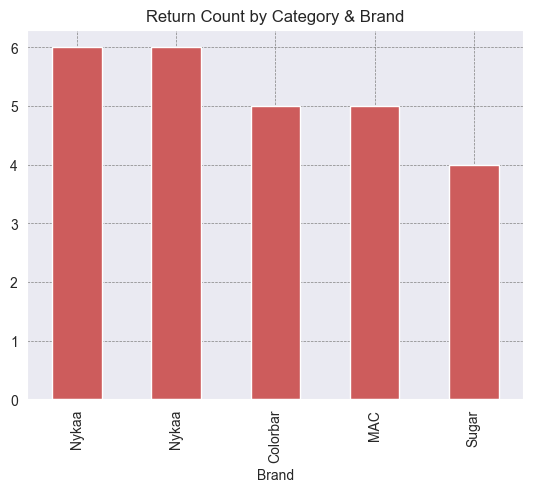

In [32]:
q60 = df[df["Returned"] == 1].groupby(["Category","Brand"]).agg({
    "Discount_Percent": lambda x: round(x.mean(),2),
    "Price_INR": lambda x: round(x.mean(),2),
    "Rating": lambda x: round(x.mean(),2),
    "Returned": "sum"
}).reset_index().sort_values("Returned", ascending=False)

print(q60)
print()

q60.head().plot(kind="bar", x="Brand", y="Returned", legend=False, color="indianred")
plt.title("Return Count by Category & Brand")
plt.xticks(rotation=90)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

From the data, **Nykaa’s Mascara** and **Setting Spray** have the highest number of returns (6 each), followed by **Colorbar Foundation** and **MAC Eyeliner** (5 each).
The key factors appear to be:
- **Moderate ratings** (around 3.4–3.8), suggesting product satisfaction issues.
- **Higher prices** (₹819–₹1,521), which may raise customer expectations.
- **Discounts** (3–12%), possibly attracting impulse purchases that lead to returns.

In short, products with **mid-level ratings, higher prices, and moderate discounts** tend to have more returns — indicating that perceived value and performance mismatch could be driving dissatisfaction.

## Do low ratings or higher pricing increase return rates?

          Rating     Price_INR  Returned
0     Low Rating     Low Price     24.59
1     Low Rating  Medium Price      4.47
2     Low Rating    High Price      5.70
3  Medium Rating     Low Price      8.05
4  Medium Rating  Medium Price     11.70
5  Medium Rating    High Price      8.80
6    High Rating     Low Price     11.46
7    High Rating  Medium Price      9.79
8    High Rating    High Price     10.44


C:\Users\USER\AppData\Local\Temp\ipykernel_20408\1851778144.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q62 = df.groupby([


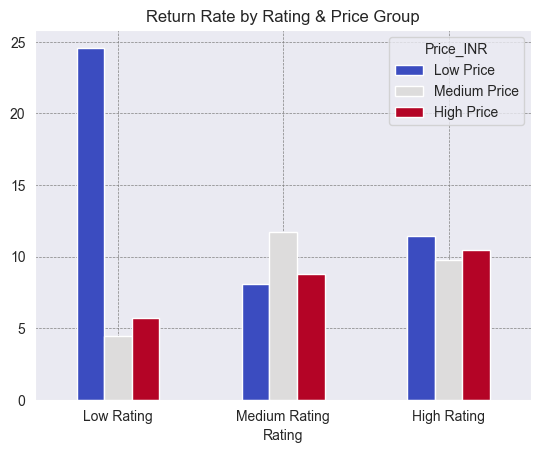

In [33]:
q62 = df.groupby([
    pd.cut(df["Rating"], bins=[0,3,4,5], labels=["Low Rating","Medium Rating","High Rating"]),
    pd.cut(df["Price_INR"], bins=[0,500,1500,float("inf")], labels=["Low Price","Medium Price","High Price"])
]).agg({
    "Returned": lambda x: round(x.mean()*100,2)
}).reset_index()

print(q62)

heatmap_data = q62.pivot(index="Rating", columns="Price_INR", values="Returned")

heatmap_data.plot(kind="bar", colormap="coolwarm")
plt.title("Return Rate by Rating & Price Group")
plt.xticks(rotation=0)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

The data clearly shows that **low-rated products with low prices** have the **highest return rate (24.59%)**, while **high-priced or highly rated items** have much lower return rates (around 10%).

This suggests that **low ratings** are a stronger driver of returns than pricing — customers are more likely to return products they’re dissatisfied with, regardless of cost. However, **cheap, low-rated items** seem especially prone to returns, possibly due to lower perceived quality or impulse buying behavior.

## Which products have the highest return rates?

         Brand       Category  Returned  Units_Sold  Return_Rate_Percent
77       Nykaa        Mascara         6         232                 2.59
90       Sugar          Blush         4         293                 1.37
42         MAC       Eyeliner         5         449                 1.11
1     Colorbar      Concealer         4         391                 1.02
79       Nykaa  Setting Spray         6         693                 0.87
..         ...            ...       ...         ...                  ...
47         MAC        Mascara         1         554                 0.18
58  Maybelline         Primer         1         593                 0.17
94       Sugar     Foundation         1         578                 0.17
95       Sugar    Highlighter         1         577                 0.17
57  Maybelline        Mascara         1         624                 0.16

[84 rows x 5 columns]



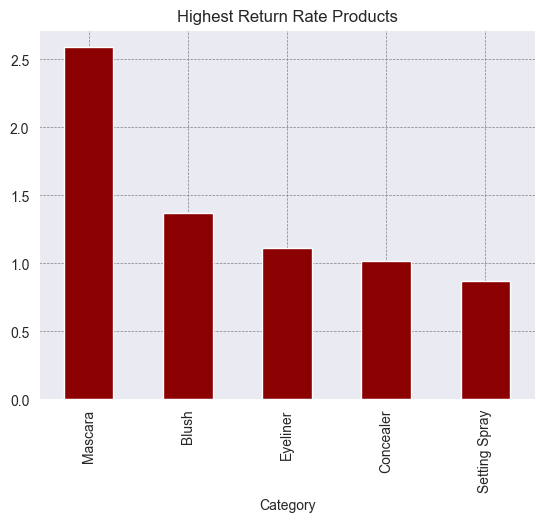

In [35]:
q63 = df.groupby(["Brand","Category"]).agg({
    "Returned": "sum",
    "Units_Sold": "sum"
}).reset_index()

q63["Return_Rate_Percent"] = round(q63["Returned"]/q63["Units_Sold"]*100,2)
q63 = q63[q63["Returned"]>0].sort_values(["Return_Rate_Percent","Returned"], ascending=[False,False])

print(q63)
print()

q63.head().plot(kind="bar", x="Category", y="Return_Rate_Percent", legend=False, color="darkred")
plt.title("Highest Return Rate Products")
plt.xticks(rotation=90)
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()

The products with the **highest return rates** are **Nykaa Mascara** (2.59%) and **Sugar Blush** (1.37%), followed by **MAC Eyeliner** (1.11%) and **Colorbar Concealer** (1.02%).

This pattern suggests that **eye and face products**—especially those with complex application or shade matching—tend to have higher return rates. It’s likely driven by **customer dissatisfaction with texture, color accuracy, or performance expectations**, making these categories prime candidates for quality improvement or clearer product descriptions.